# Lab: K-Means Clustering with scikit-learn

In the [clustering overview](./01_clustering_strategies_and_real-world_applications.md), we learned the three families of clustering algorithms (partition-based, density-based, hierarchical) and their real-world applications.

In the [K-Means theory](./02_k-means_clustering_theory.md), we learned how K-Means works: initialize centroids → assign points to the nearest centroid → update centroids to the cluster mean → repeat until convergence. The objective is to minimize **inertia** (within-cluster sum of squares, WCSS).

In the [from-scratch implementation](./03_k-means_clustering_implementation.py), we coded the full algorithm with NumPy — centroid initialization, distance computation, cluster assignment, and centroid updates.

**Now it's time to use the real thing.** In this lab, we'll learn how to:

1. Load and prepare data for K-Means clustering.
2. **Understand why scaling matters** for distance-based algorithms.
3. **Use scikit-learn's `KMeans`** to fit a clustering model.
4. **Inspect what the model learned** — centroids, labels, and inertia.
5. **Choose k** using the Elbow Method.
6. **Visualize clusters** in 2D and 3D.
7. **Profile clusters** to understand what each group represents.
8. **Understand the limitations** by seeing where K-Means fails.

---

## 1. The Dataset

We'll use the **Mall Customers** dataset — a classic customer segmentation dataset from [Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data). It contains 200 customers from a shopping mall loyalty program with 3 numerical features:

| Feature | Description | Range |
|---|---|---|
| `age` | Customer's age in years | 18–70 |
| `annual_income` | Annual income in thousands of dollars | 15–137 |
| `spending_score` | Mall-assigned behavior/spending score | 1–99 |

This dataset is ideal for learning K-Means because:
- It has **no labels** — a true unsupervised problem.
- It has **natural clusters** visible in the income-vs-spending space.
- It's small enough to visualize and understand completely.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load and prepare the dataset
from pathlib import Path

raw_df = pd.read_csv(Path("../data/raw/Mall_Customers.csv"))

# Rename columns to snake_case
df = raw_df.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
})

print(f"Dataset: {df.shape[0]} customers, {df.shape[1]} columns")
print(f"Numerical features: age, annual_income, spending_score")
print(f"No missing values: {df.isnull().sum().sum() == 0}")
print()
df.sample(5, random_state=42)

Dataset: 200 customers, 5 columns
Numerical features: age, annual_income, spending_score
No missing values: True



,customer_id,gender,age,annual_income,spending_score
95,96,Male,24,60,52
15,16,Male,22,20,79
30,31,Male,60,30,4
158,159,Male,34,78,1
128,129,Male,59,71,11


---

## 2. Quick Visual Exploration

Before clustering, let's look at the data to build intuition about what clusters might exist. We'll focus on the most revealing pair: **annual income vs. spending score**.

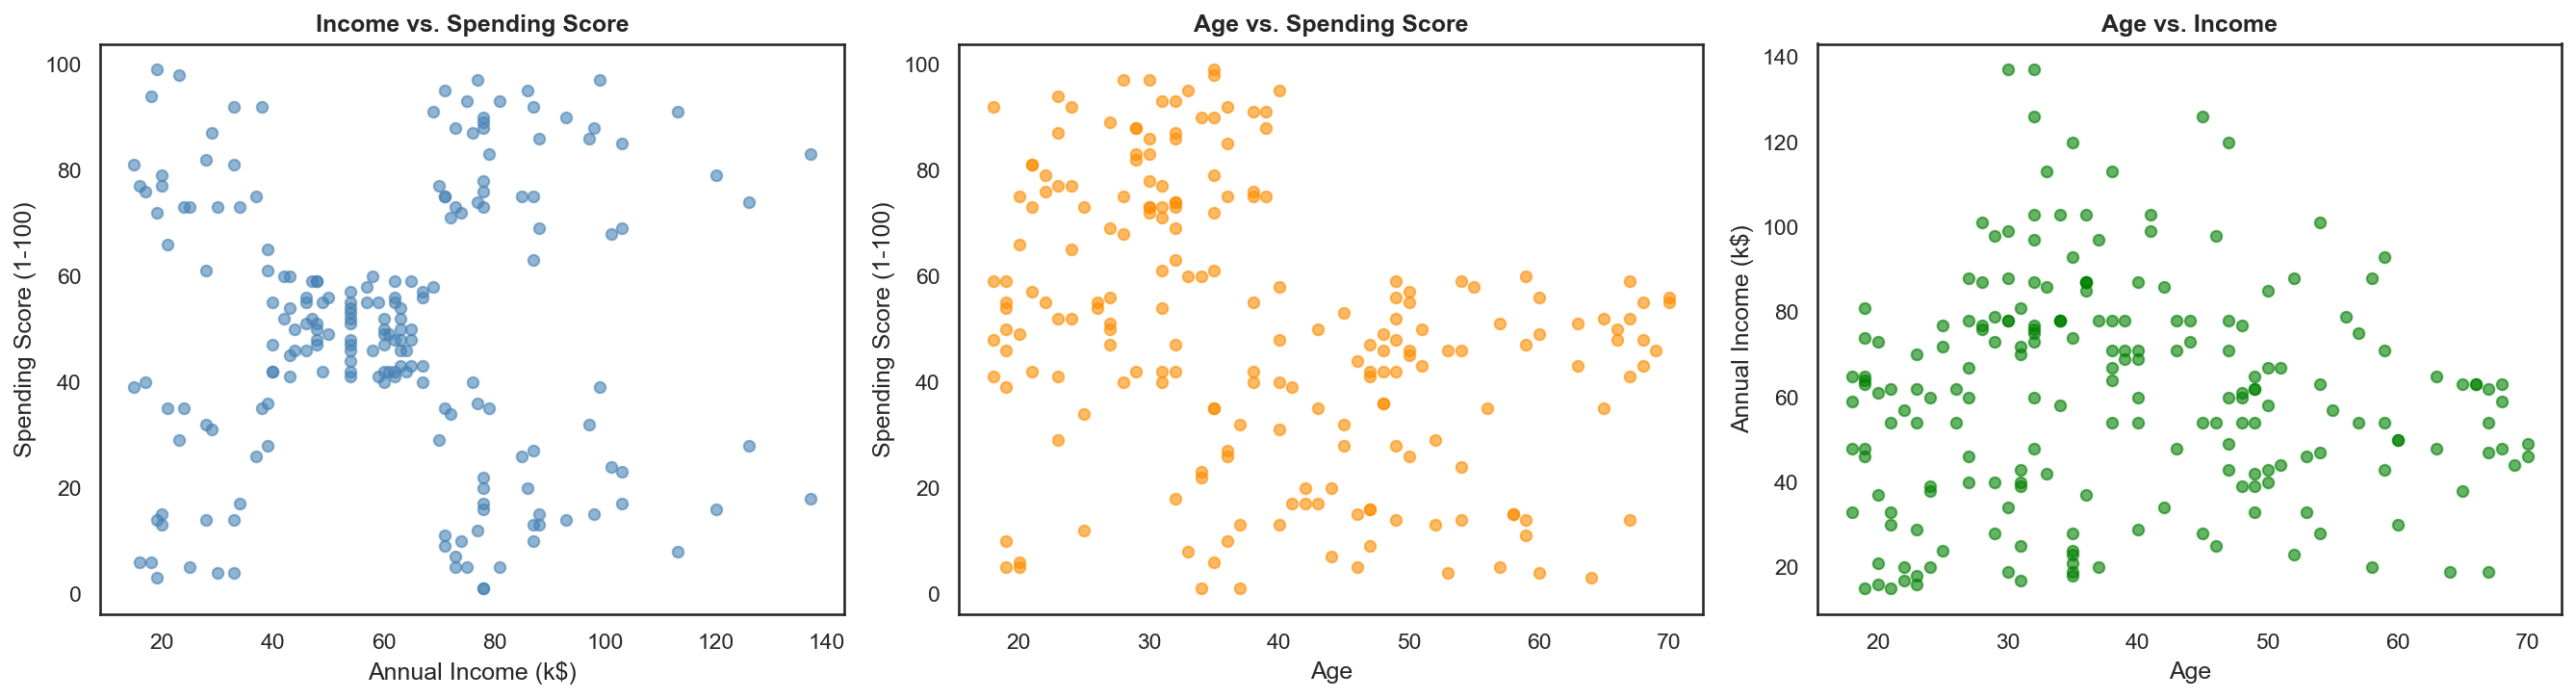

📌 The Income vs. Spending Score plot (left) shows CLEAR natural groupings!
   You can probably see ~5 blobs with your eyes. This is exactly what K-Means will find.
   The other two pairs show much less structure — age doesn't separate customers as cleanly.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Income vs Spending Score — the most interesting pair
axes[0].scatter(df["annual_income"], df["spending_score"], alpha=0.6, s=30, color="steelblue")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")
axes[0].set_title("Income vs. Spending Score", fontweight="bold")

# Age vs Spending Score
axes[1].scatter(df["age"], df["spending_score"], alpha=0.6, s=30, color="darkorange")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Spending Score (1-100)")
axes[1].set_title("Age vs. Spending Score", fontweight="bold")

# Age vs Income
axes[2].scatter(df["age"], df["annual_income"], alpha=0.6, s=30, color="green")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Annual Income (k$)")
axes[2].set_title("Age vs. Income", fontweight="bold")

plt.tight_layout()
plt.show()

print("📌 The Income vs. Spending Score plot (left) shows CLEAR natural groupings!")
print("   You can probably see ~5 blobs with your eyes. This is exactly what K-Means will find.")
print("   The other two pairs show much less structure — age doesn't separate customers as cleanly.")

---

## 3. Why Scaling Matters for K-Means

From the theory:
> *K-Means uses **distance** (Euclidean by default) to assign points to clusters.*

If features have different scales, the feature with the largest range will **dominate** the distance calculation. In our data:
- `age`: 18–70 (range ~52)
- `annual_income`: 15–137 (range ~122)
- `spending_score`: 1–99 (range ~98)

`annual_income` has more than double the range of `age`, so without scaling, K-Means would care much more about income differences than age differences.

**StandardScaler** transforms each feature to have mean=0 and std=1, making them equally important in distance calculations.

In [4]:
# Select numerical features for clustering
feature_cols = ["age", "annual_income", "spending_score"]
X = df[feature_cols].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compare before and after
print("Before scaling:")
print(f"  age        — mean: {X[:, 0].mean():.1f},  std: {X[:, 0].std():.1f}")
print(f"  income     — mean: {X[:, 1].mean():.1f}, std: {X[:, 1].std():.1f}")
print(f"  spending   — mean: {X[:, 2].mean():.1f}, std: {X[:, 2].std():.1f}")
print()
print("After scaling:")
print(f"  age        — mean: {X_scaled[:, 0].mean():.1f},  std: {X_scaled[:, 0].std():.1f}")
print(f"  income     — mean: {X_scaled[:, 1].mean():.1f},  std: {X_scaled[:, 1].std():.1f}")
print(f"  spending   — mean: {X_scaled[:, 2].mean():.1f},  std: {X_scaled[:, 2].std():.1f}")
print()
print("📌 After scaling, all features have mean≈0 and std≈1.")
print("   Now K-Means will treat age, income, and spending score equally.")

Before scaling:
  age        — mean: 38.9,  std: 13.9
  income     — mean: 60.6, std: 26.2
  spending   — mean: 50.2, std: 25.8

After scaling:
  age        — mean: -0.0,  std: 1.0
  income     — mean: -0.0,  std: 1.0
  spending   — mean: -0.0,  std: 1.0

📌 After scaling, all features have mean≈0 and std≈1.
   Now K-Means will treat age, income, and spending score equally.


Let's **prove** that scaling matters by clustering with and without it:

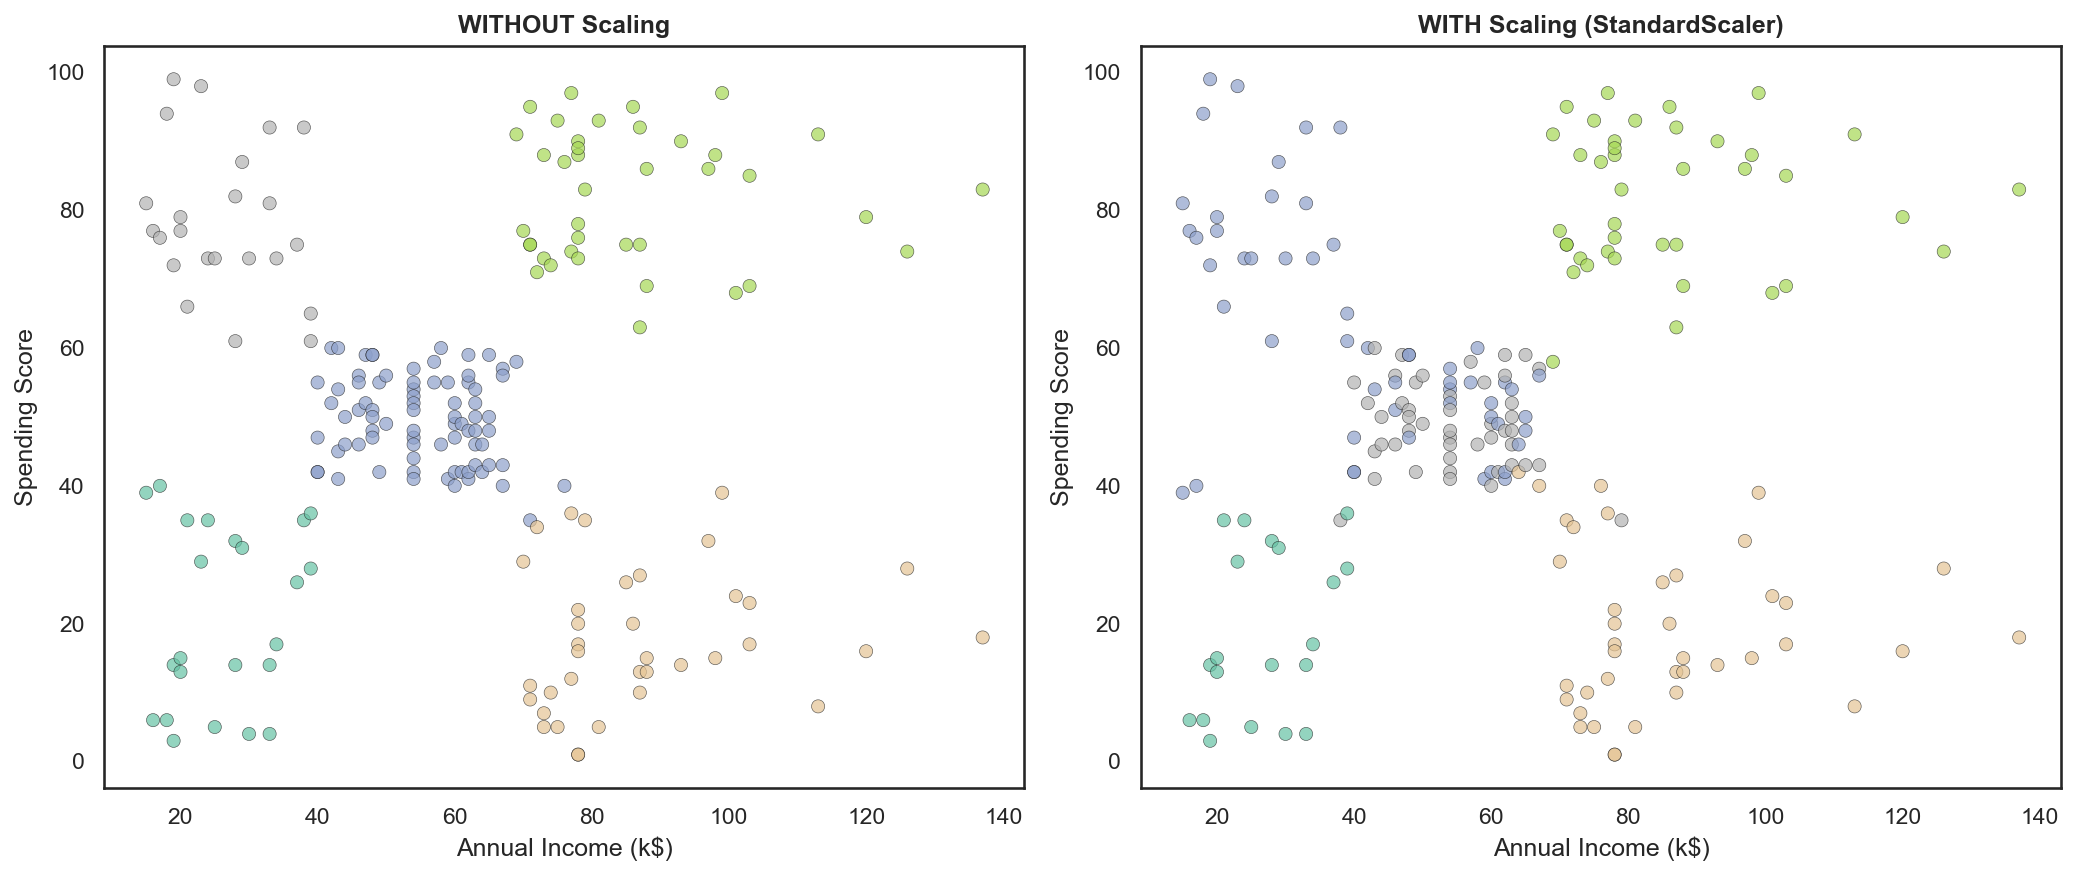

📌 Without scaling, income dominates — clusters split primarily along the income axis.
   With scaling, K-Means finds the natural 5-group structure we saw by eye.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title in zip(axes, [X, X_scaled],
                            ["WITHOUT Scaling", "WITH Scaling (StandardScaler)"]):
    km = KMeans(n_clusters=5, random_state=42, n_init=10)
    labels = km.fit_predict(data)

    # Plot in income-spending space (original units for visualization)
    scatter = ax.scatter(df["annual_income"], df["spending_score"],
                         c=labels, cmap="Set2", s=40, alpha=0.7, edgecolors="k", linewidths=0.3)
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score")
    ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.show()

print("📌 Without scaling, income dominates — clusters split primarily along the income axis.")
print("   With scaling, K-Means finds the natural 5-group structure we saw by eye.")

---

## 4. Fitting K-Means with scikit-learn

scikit-learn's `KMeans` key parameters:

| Parameter | What It Does | Default |
|---|---|---|
| `n_clusters` | Number of clusters ($k$) | 8 |
| `init` | Initialization method | `'k-means++'` (smart init) |
| `n_init` | Number of times to run with different seeds | 10 |
| `max_iter` | Max iterations per run | 300 |
| `random_state` | Seed for reproducibility | `None` |

Let's start with k=5 (we'll learn how to choose k properly in Section 6):

In [6]:
# Fit K-Means with k=5
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10,
    random_state=42
)
kmeans.fit(X_scaled)

print("KMeans model fitted!")
print(f"  n_clusters: {kmeans.n_clusters}")
print(f"  init: {kmeans.init}")
print(f"  n_init: {kmeans.n_init} (ran K-Means 10 times, kept the best)")
print(f"  n_iter_: {kmeans.n_iter_} iterations to converge (on the best run)")
print(f"  inertia_: {kmeans.inertia_:.2f} (within-cluster sum of squares)")

KMeans model fitted!
  n_clusters: 5
  init: k-means++
  n_init: 10 (ran K-Means 10 times, kept the best)
  n_iter_: 9 iterations to converge (on the best run)
  inertia_: 168.25 (within-cluster sum of squares)


---

## 5. Inspecting the Model: Labels, Centroids, and Inertia

After fitting, the `KMeans` object stores:
- `.labels_` — The cluster assignment (0, 1, 2, ...) for each data point.
- `.cluster_centers_` — The centroid coordinates (in scaled space).
- `.inertia_` — The total WCSS (the objective function K-Means minimizes).

In [7]:
# Cluster labels for each customer
print("Cluster labels (first 20 customers):")
print(kmeans.labels_[:20])
print()

# How many customers in each cluster?
unique, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} customers ({count/len(kmeans.labels_)*100:.0f}%)")

print(f"\n📌 K-Means assigned each of the {len(kmeans.labels_)} customers to one of {kmeans.n_clusters} clusters.")
print(f"   The cluster sizes are not equal — that's normal and expected.")

Cluster labels (first 20 customers):
[1 1 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]

Cluster sizes:
  Cluster 0: 20 customers (10%)
  Cluster 1: 54 customers (27%)
  Cluster 2: 40 customers (20%)
  Cluster 3: 39 customers (20%)
  Cluster 4: 47 customers (24%)

📌 K-Means assigned each of the 200 customers to one of 5 clusters.
   The cluster sizes are not equal — that's normal and expected.


In [8]:
# Centroids (in scaled space)
print("Centroids (in scaled space):")
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
print(centroids_scaled.round(2))
print()

# Transform centroids back to original space for interpretation
centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_cols
)
centroids_original.index.name = "Cluster"
print("Centroids (in ORIGINAL space — interpretable):")
print(centroids_original.round(1))
print()
print("📌 The centroids are the 'average customer' in each cluster.")
print("   We use scaler.inverse_transform() to convert back to real-world units.")

Centroids (in scaled space):
    age  annual_income  spending_score
0  0.53          -1.29           -1.24
1 -0.98          -0.74            0.47
2 -0.43           0.97            1.22
3  0.07           0.97           -1.20
4  1.20          -0.24           -0.05

Centroids (in ORIGINAL space — interpretable):
          age  annual_income  spending_score
Cluster                                     
0        46.2           26.8            18.3
1        25.2           41.1            62.2
2        32.9           86.1            81.5
3        39.9           86.1            19.4
4        55.6           54.4            48.9

📌 The centroids are the 'average customer' in each cluster.
   We use scaler.inverse_transform() to convert back to real-world units.


---

## 6. Choosing k: The Elbow Method

From the theory:
> *"Plot the Inertia (WCSS) against different values of k. Look for the 'elbow' point where the reduction in variance slows down significantly."*

The idea is simple:
- **k=1**: All points in one cluster → maximum inertia.
- **k=n**: Each point is its own cluster → inertia = 0.
- **The sweet spot**: Somewhere in between, where adding more clusters stops being worth it.

Let's run K-Means for k=1 through k=10 and plot the inertia:

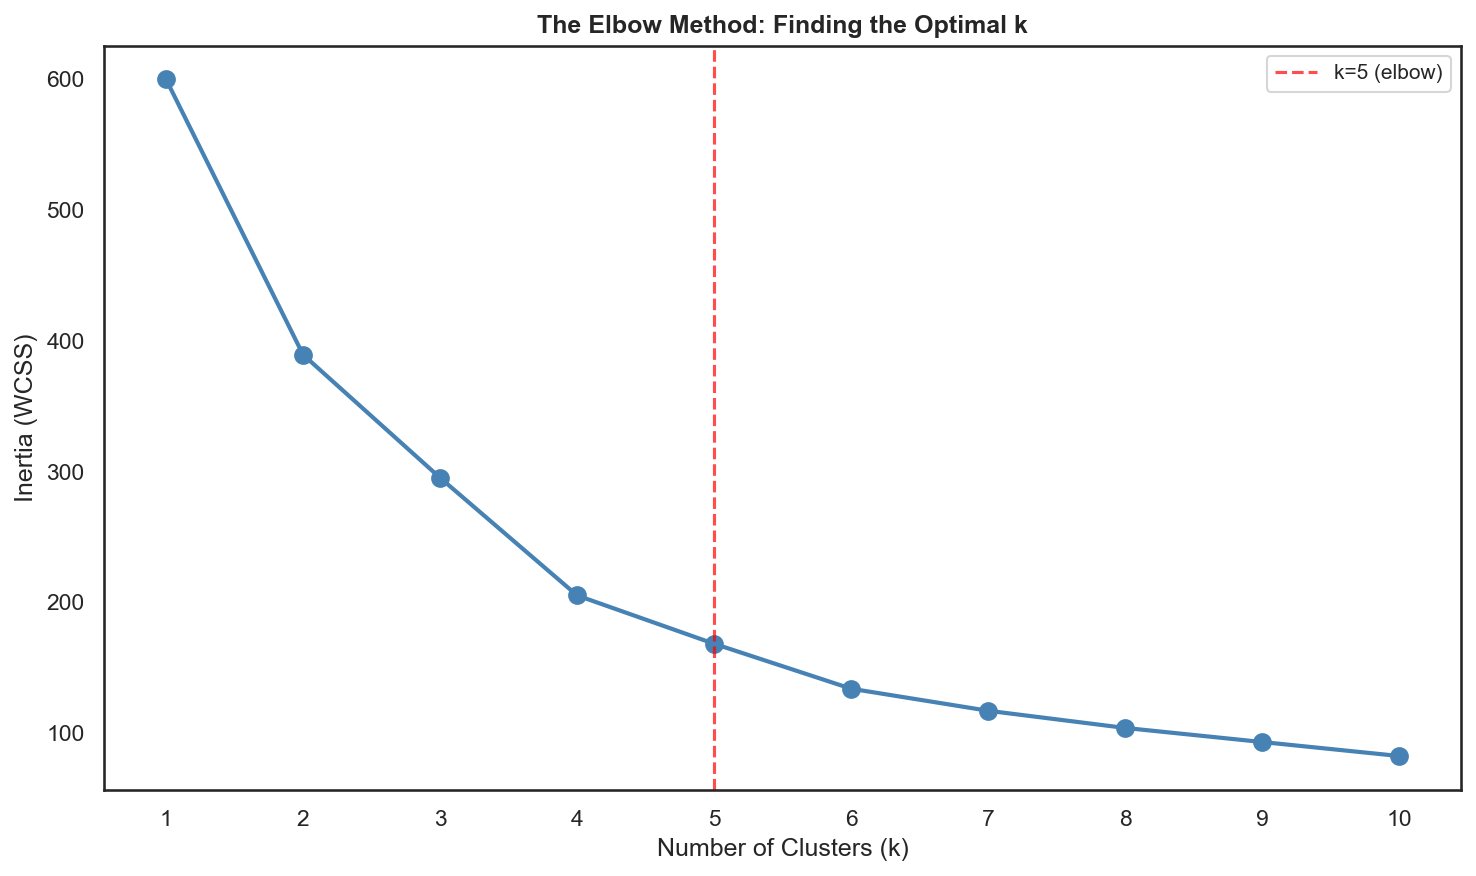

📌 Inertia drops sharply from k=1 to k=5, then the curve 'bends' — the elbow.
   After k=5, adding more clusters gives diminishing returns.
   This suggests k=5 is a good choice for this dataset.

Inertia values:
  k= 1:  600.00
  k= 2:  389.39  (↓ 210.6)
  k= 3:  295.21  (↓ 94.2)
  k= 4:  205.23  (↓ 90.0)
  k= 5:  168.25  (↓ 37.0) ← elbow
  k= 6:  133.87  (↓ 34.4)
  k= 7:  117.01  (↓ 16.9)
  k= 8:  103.87  (↓ 13.1)
  k= 9:   93.09  (↓ 10.8)
  k=10:   82.39  (↓ 10.7)


In [9]:
# Run K-Means for different values of k
k_range = range(1, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot the Elbow curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, inertias, "o-", color="steelblue", linewidth=2, markersize=8)
ax.axvline(x=5, color="red", linestyle="--", alpha=0.7, label="k=5 (elbow)")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (WCSS)")
ax.set_title("The Elbow Method: Finding the Optimal k", fontweight="bold")
ax.set_xticks(list(k_range))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("📌 Inertia drops sharply from k=1 to k=5, then the curve 'bends' — the elbow.")
print("   After k=5, adding more clusters gives diminishing returns.")
print("   This suggests k=5 is a good choice for this dataset.")
print()
print("Inertia values:")
for k, inertia in zip(k_range, inertias):
    drop = "" if k == 1 else f"  (↓ {inertias[k-2] - inertia:.1f})"
    marker = " ← elbow" if k == 5 else ""
    print(f"  k={k:2d}: {inertia:7.2f}{drop}{marker}")

---

## 7. Visualizing the Clusters

Now let's visualize our k=5 clustering result. We'll look at both the 2D income-spending view and a full 3D view.

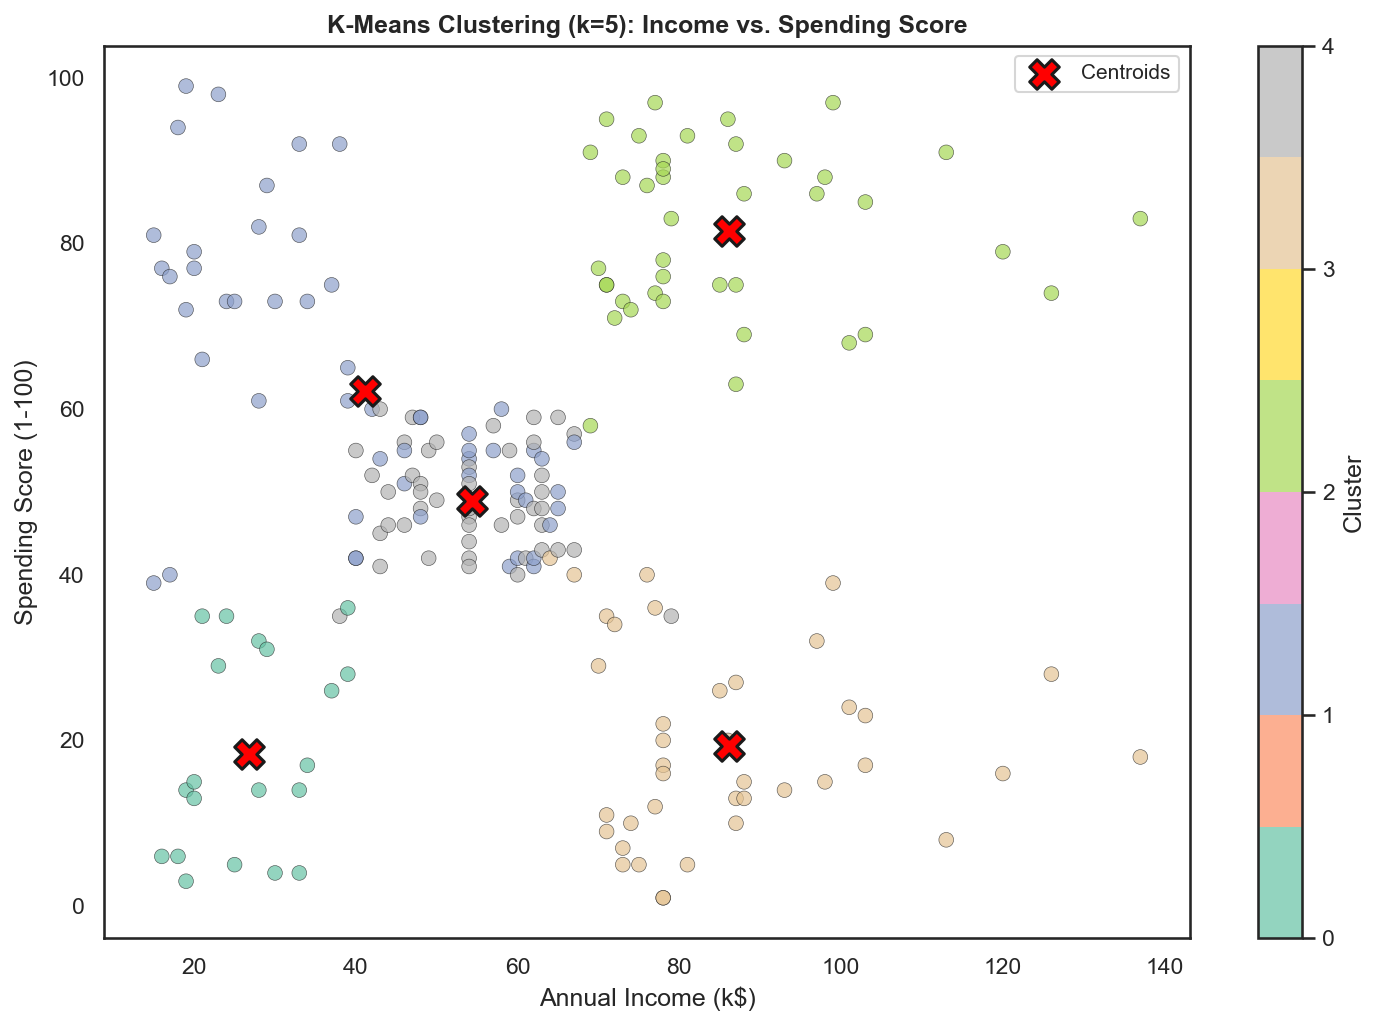

📌 The red X markers are the centroids — the 'center' of each cluster.
   Each point is colored by its cluster assignment.
   The 5 groups match what we visually spotted in the raw scatter plot!


In [10]:
# 2D visualization: Income vs. Spending Score
labels = kmeans.labels_

# Get centroids in original space
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df["annual_income"], df["spending_score"],
                     c=labels, cmap="Set2", s=50, alpha=0.7,
                     edgecolors="k", linewidths=0.3)

# Plot centroids
ax.scatter(centers_orig[:, 1], centers_orig[:, 2],
           c="red", marker="X", s=200, edgecolors="k", linewidths=1.5,
           zorder=5, label="Centroids")

ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")
ax.set_title("K-Means Clustering (k=5): Income vs. Spending Score", fontweight="bold")
ax.legend(fontsize=10)
plt.colorbar(scatter, label="Cluster", ticks=range(5))
plt.tight_layout()
plt.show()

print("📌 The red X markers are the centroids — the 'center' of each cluster.")
print("   Each point is colored by its cluster assignment.")
print("   The 5 groups match what we visually spotted in the raw scatter plot!")

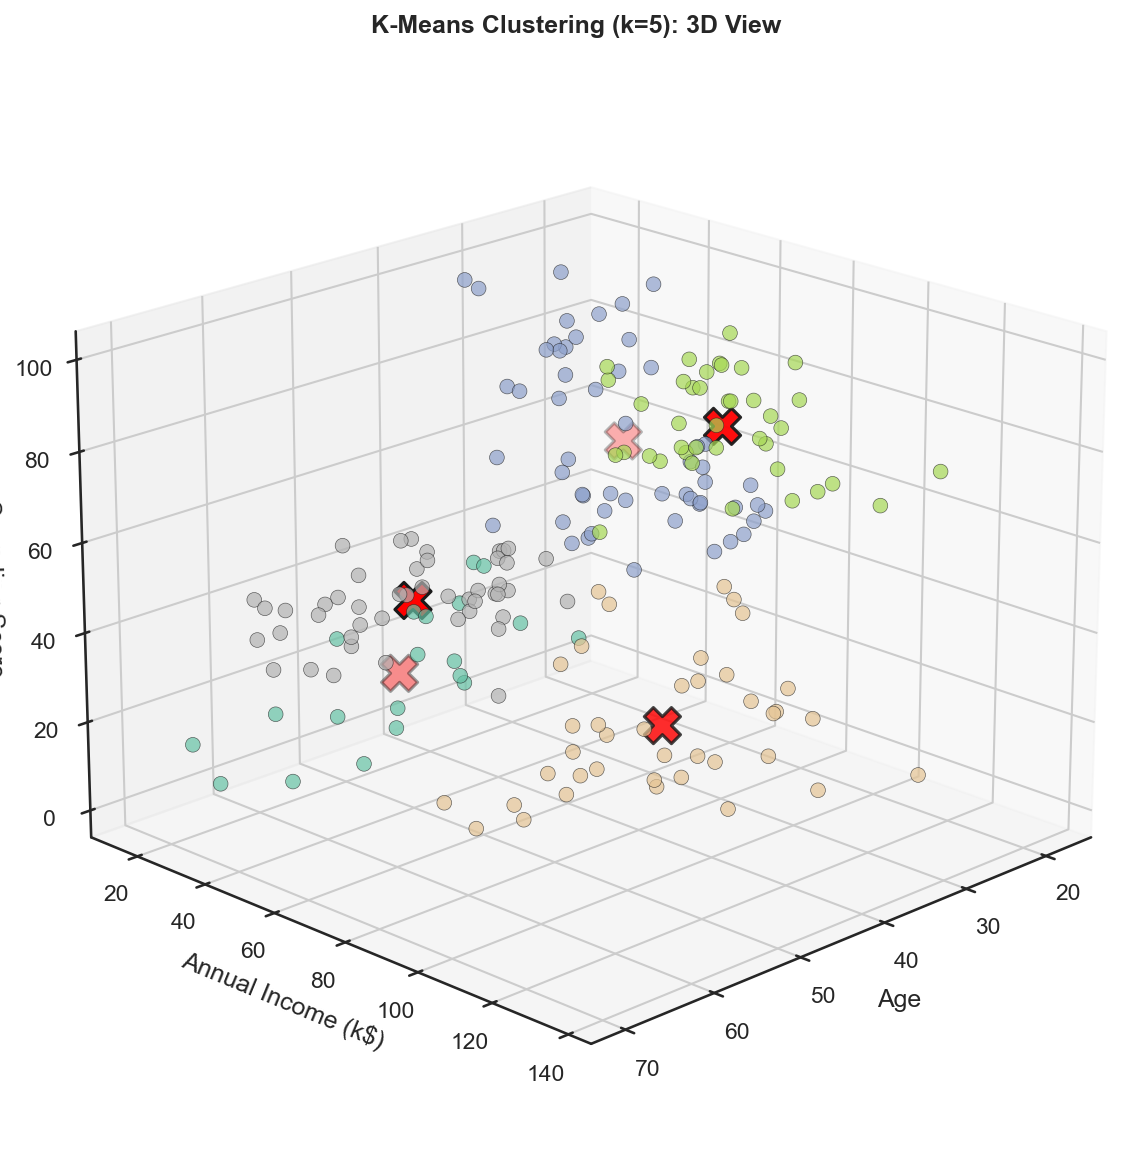

📌 The 3D view shows how the clusters separate in all three dimensions.
   Some clusters that overlap in 2D are actually well-separated in 3D.


In [11]:
# 3D visualization: all three features
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(df["age"], df["annual_income"], df["spending_score"],
                     c=labels, cmap="Set2", s=50, alpha=0.7,
                     edgecolors="k", linewidths=0.3)

# Plot centroids
ax.scatter(centers_orig[:, 0], centers_orig[:, 1], centers_orig[:, 2],
           c="red", marker="X", s=300, edgecolors="k", linewidths=1.5)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score")
ax.set_title("K-Means Clustering (k=5): 3D View", fontweight="bold")
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

print("📌 The 3D view shows how the clusters separate in all three dimensions.")
print("   Some clusters that overlap in 2D are actually well-separated in 3D.")

---

## 8. Cluster Profiling: Understanding What Each Group Means

Numbers and colors are meaningless without interpretation. The most important step in clustering is **profiling** — understanding the characteristics of each cluster. We do this by computing the mean of each feature per cluster.

In [12]:
# Add cluster labels to the DataFrame
df["cluster"] = labels

# Compute cluster profiles
profile = df.groupby("cluster")[feature_cols].agg(["mean", "std", "count"]).round(1)

# Simplify: just show means and counts
profile_simple = df.groupby("cluster")[feature_cols].mean().round(1)
profile_simple["size"] = df.groupby("cluster").size()
profile_simple["pct"] = (profile_simple["size"] / len(df) * 100).round(1)

print("Cluster Profiles (mean values):")
print(profile_simple)
print()

Cluster Profiles (mean values):
          age  annual_income  spending_score  size   pct
cluster                                                 
0        46.2           26.8            18.4    20  10.0
1        25.2           41.1            62.2    54  27.0
2        32.9           86.1            81.5    40  20.0
3        39.9           86.1            19.4    39  19.5
4        55.6           54.4            48.9    47  23.5



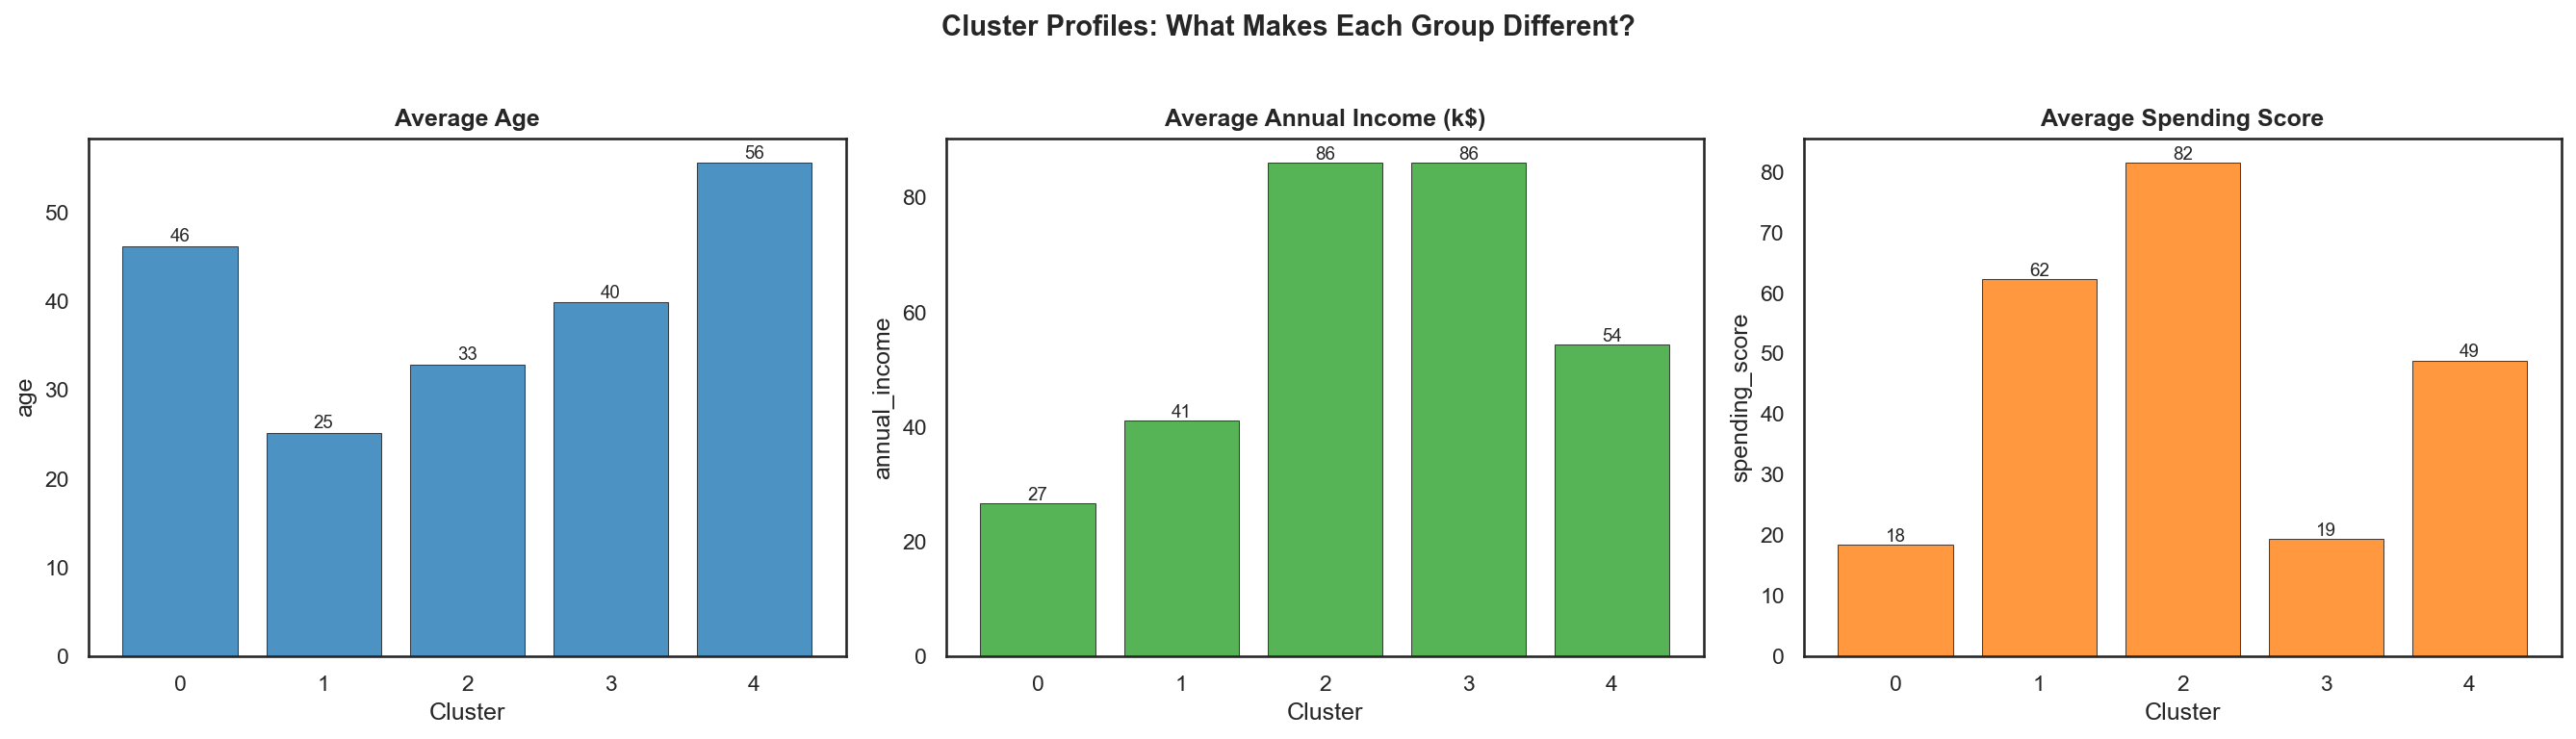

📌 Now we can NAME each cluster based on its profile:
   Look at the income and spending bars — they tell the story.
   For example, a cluster with HIGH income + HIGH spending = 'Big Spenders'.
   A cluster with HIGH income + LOW spending = 'Savers / Conservative'.


In [13]:
# Visualize cluster profiles as a grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title, color in zip(axes, feature_cols,
                                  ["Average Age", "Average Annual Income (k$)", "Average Spending Score"],
                                  ["#1f77b4", "#2ca02c", "#ff7f0e"]):
    means = df.groupby("cluster")[col].mean()
    bars = ax.bar(means.index, means.values, color=color, alpha=0.8, edgecolor="k", linewidth=0.5)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(col)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(5))

    # Add value labels on bars
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.0f}", ha="center", fontsize=9)

plt.suptitle("Cluster Profiles: What Makes Each Group Different?", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📌 Now we can NAME each cluster based on its profile:")
print("   Look at the income and spending bars — they tell the story.")
print("   For example, a cluster with HIGH income + HIGH spending = 'Big Spenders'.")
print("   A cluster with HIGH income + LOW spending = 'Savers / Conservative'.")

In [14]:
# Let's assign interpretable names based on the profiles
# (The exact cluster numbers may vary by run, so we name them by their centroid characteristics)

cluster_profiles = df.groupby("cluster")[["annual_income", "spending_score"]].mean()

def name_cluster(row):
    income = "High" if row["annual_income"] > 70 else "Low" if row["annual_income"] < 45 else "Mid"
    spending = "High" if row["spending_score"] > 60 else "Low" if row["spending_score"] < 40 else "Mid"
    return f"{income} Income / {spending} Spending"

cluster_names = cluster_profiles.apply(name_cluster, axis=1)

print("Cluster Names (based on profile):")
for cluster, name in cluster_names.items():
    size = (df["cluster"] == cluster).sum()
    print(f"  Cluster {cluster}: {name} ({size} customers)")

print("\n📌 This is the real value of clustering — it gives ACTIONABLE segments.")
print("   A marketing team can now target each group with different strategies.")

Cluster Names (based on profile):
  Cluster 0: Low Income / Low Spending (20 customers)
  Cluster 1: Low Income / High Spending (54 customers)
  Cluster 2: High Income / High Spending (40 customers)
  Cluster 3: High Income / Low Spending (39 customers)
  Cluster 4: Mid Income / Mid Spending (47 customers)

📌 This is the real value of clustering — it gives ACTIONABLE segments.
   A marketing team can now target each group with different strategies.


---

## 9. Watching K-Means Iterate: The Algorithm in Action

From the theory, K-Means alternates between **Assign** (assign points to nearest centroid) and **Update** (move centroids to cluster mean). Let's watch this happen step by step using `max_iter` to freeze the algorithm mid-convergence:

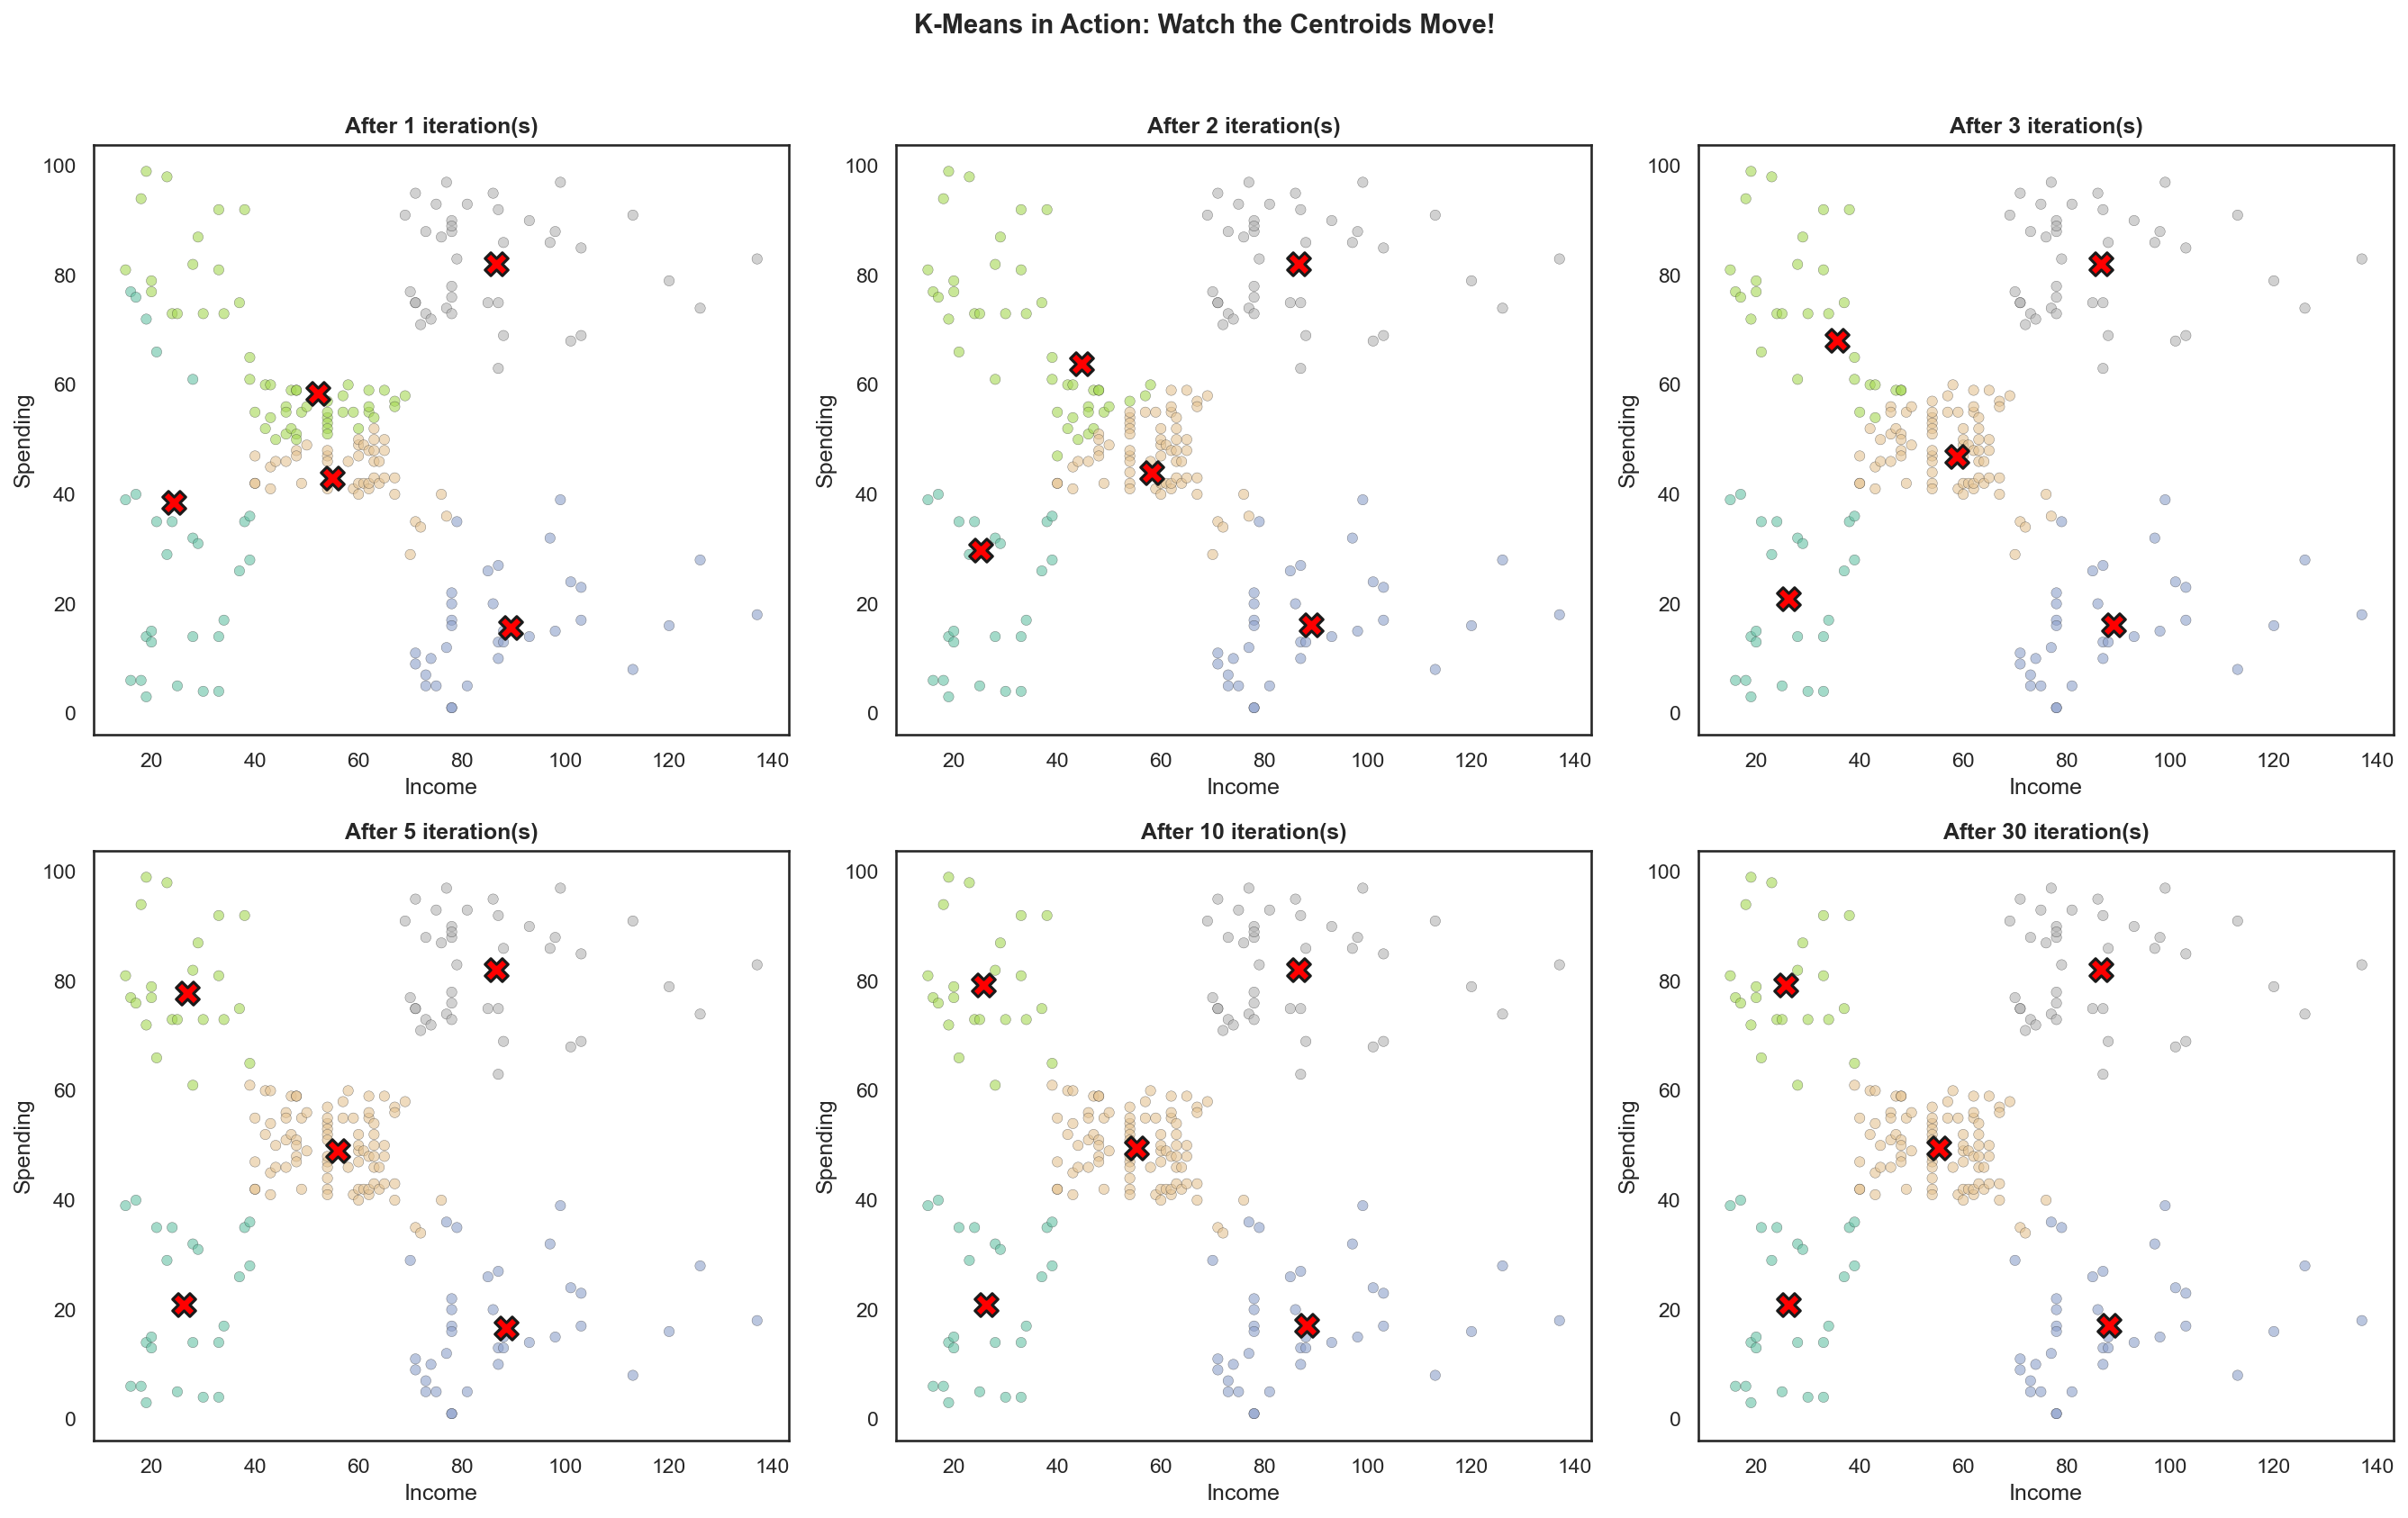

📌 Iteration 1: Random centroids, messy assignments.
   Iteration 2-3: Centroids migrate toward dense regions.
   Iteration 5+: Nearly converged — centroids barely move anymore.
   This is exactly the assign-update-repeat loop from the theory and implementation!


In [15]:
# Use only income and spending for 2D visualization
X_2d = df[["annual_income", "spending_score"]].values
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Fix the initial centroids so we can trace the iterations
np.random.seed(0)
init_idx = np.random.choice(len(X_2d_scaled), 5, replace=False)
init_centroids = X_2d_scaled[init_idx]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
iterations = [1, 2, 3, 5, 10, 30]

for ax, max_it in zip(axes.ravel(), iterations):
    km = KMeans(n_clusters=5, init=init_centroids, n_init=1,
                max_iter=max_it, random_state=42)
    km.fit(X_2d_scaled)

    # Plot in original space
    centers = scaler_2d.inverse_transform(km.cluster_centers_)
    ax.scatter(df["annual_income"], df["spending_score"],
              c=km.labels_, cmap="Set2", s=30, alpha=0.6, edgecolors="k", linewidths=0.2)
    ax.scatter(centers[:, 0], centers[:, 1],
              c="red", marker="X", s=150, edgecolors="k", linewidths=1.5, zorder=5)
    ax.set_title(f"After {max_it} iteration(s)", fontweight="bold")
    ax.set_xlabel("Income")
    ax.set_ylabel("Spending")

plt.suptitle("K-Means in Action: Watch the Centroids Move!", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📌 Iteration 1: Random centroids, messy assignments.")
print("   Iteration 2-3: Centroids migrate toward dense regions.")
print("   Iteration 5+: Nearly converged — centroids barely move anymore.")
print("   This is exactly the assign-update-repeat loop from the theory and implementation!")

---

## 10. The Role of Initialization: Why `k-means++` Matters

From the theory:
> *"K-Means can converge to different solutions depending on the initial centroid positions."*

scikit-learn defaults to `init='k-means++'`, which spreads initial centroids far apart. Let's compare random vs. k-means++ initialization:

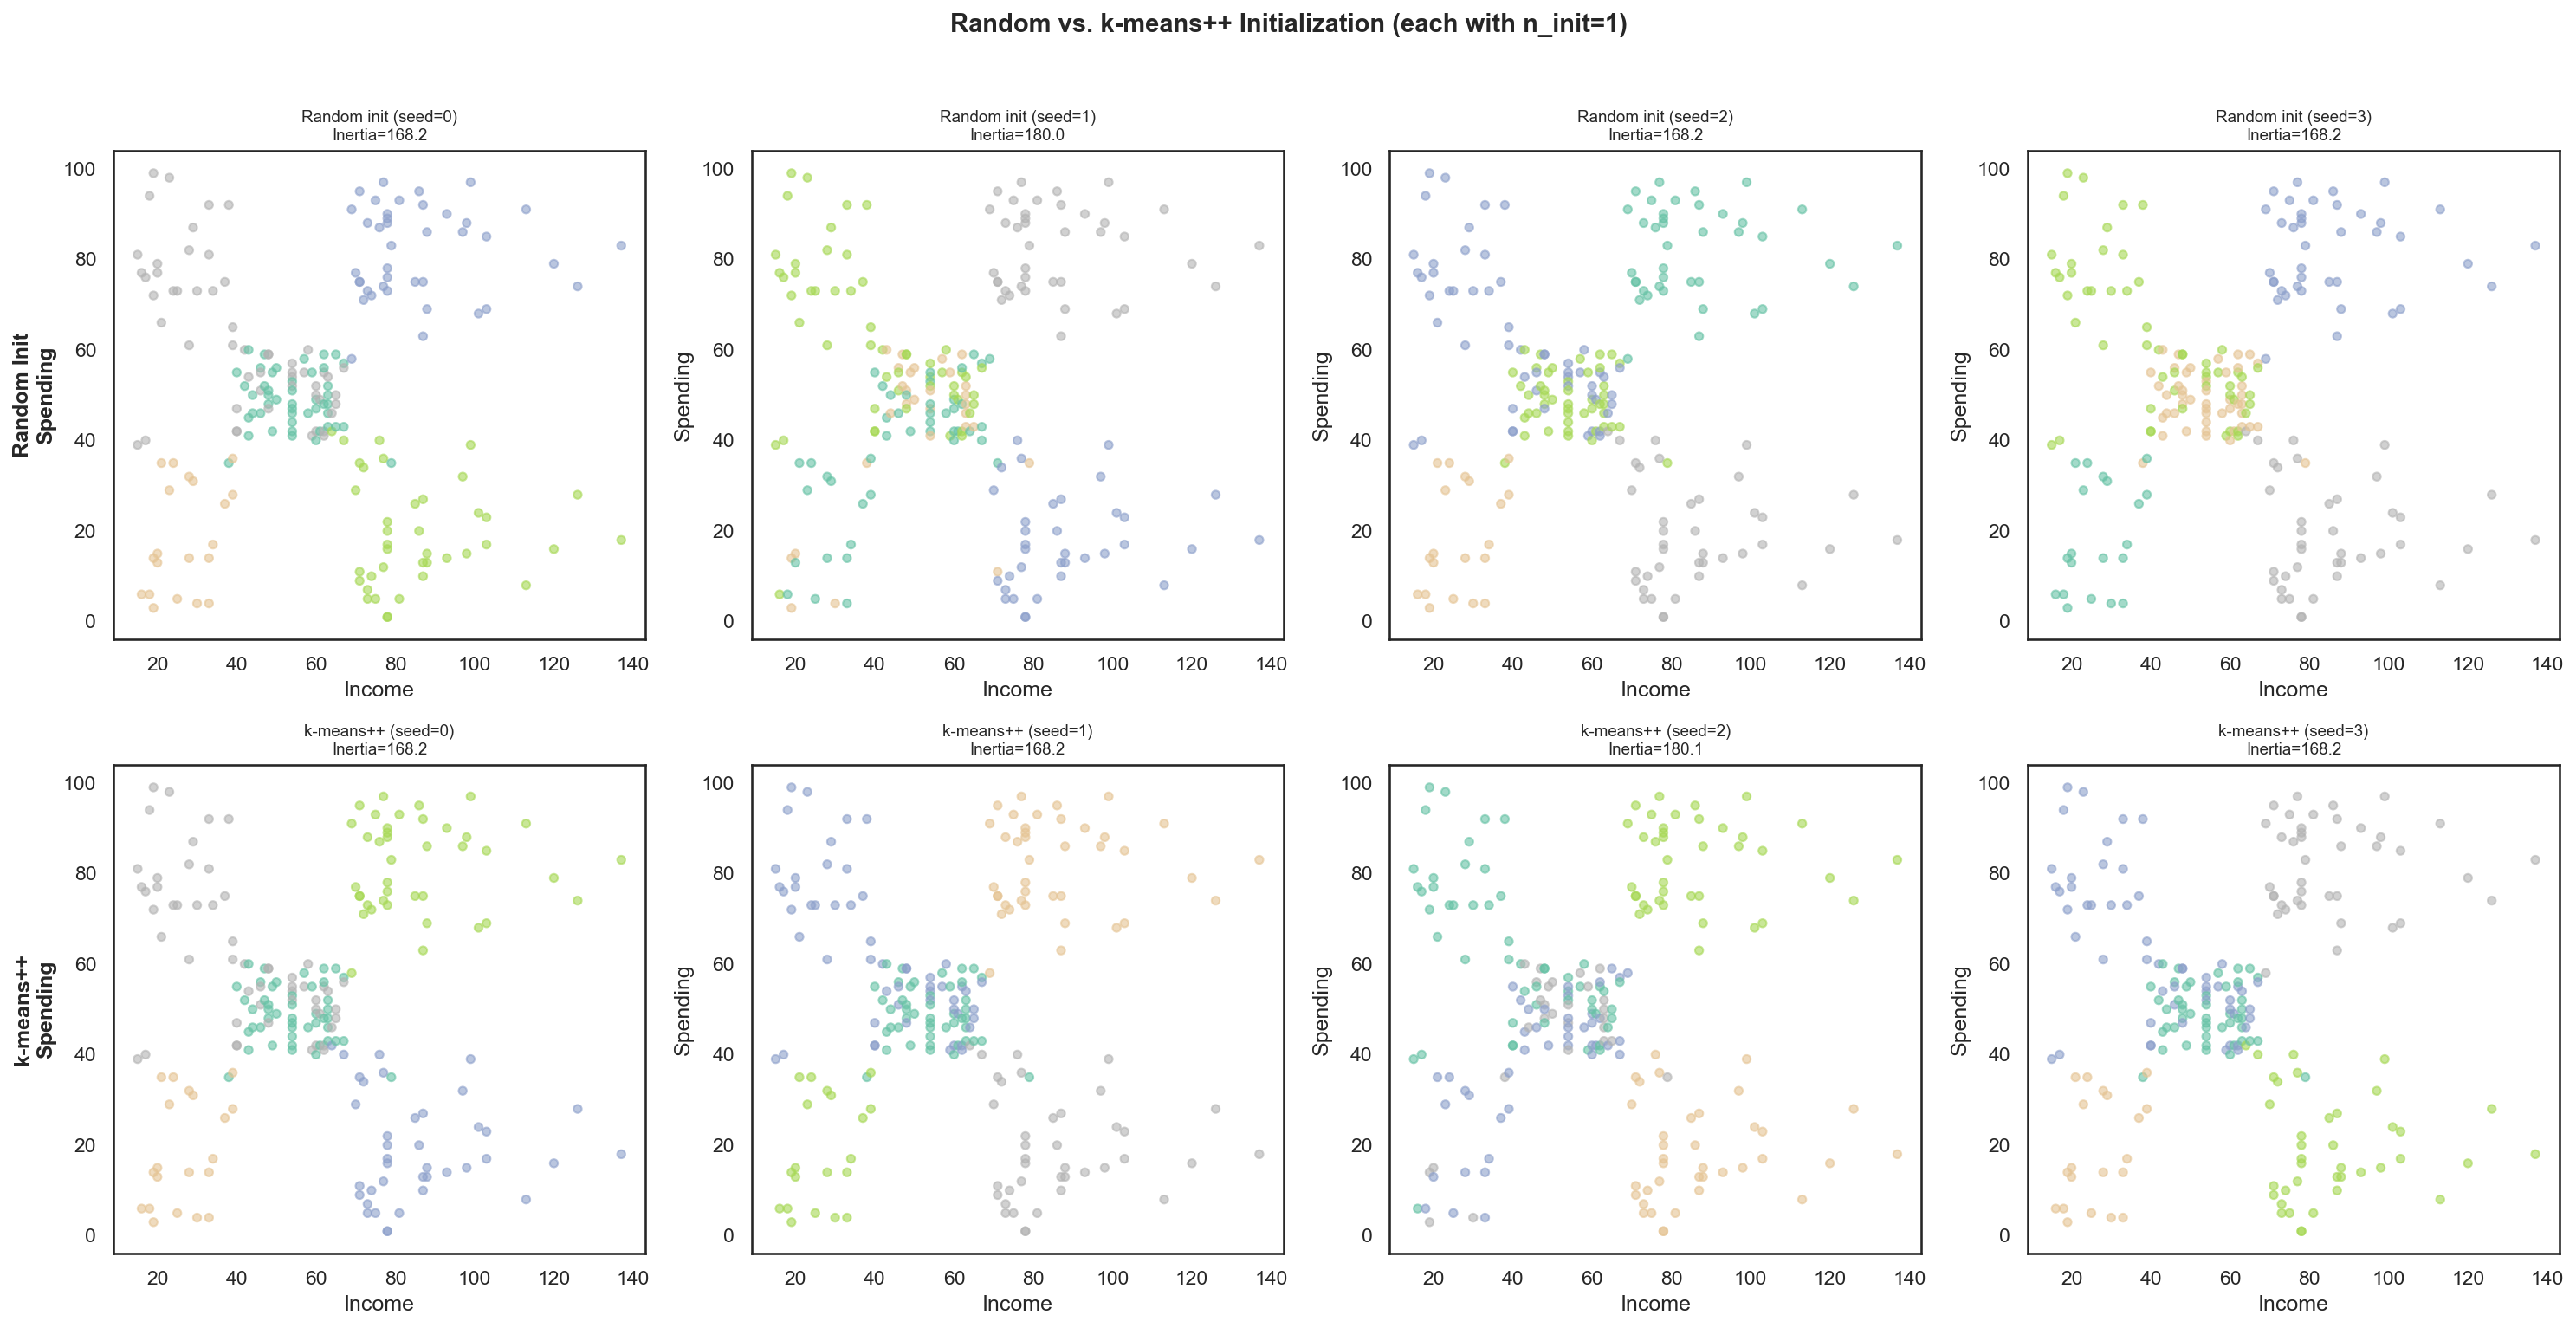

📌 Random init: Results vary wildly — some seeds give bad clusterings (high inertia).
   k-means++: Much more consistent — the smart initialization almost always finds good clusters.
   That's why scikit-learn also sets n_init=10 by default: run 10 times, keep the best.


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Top row: Random initialization with different seeds
for i, ax in enumerate(axes[0]):
    km = KMeans(n_clusters=5, init="random", n_init=1, random_state=i)
    km.fit(X_scaled)
    ax.scatter(df["annual_income"], df["spending_score"],
              c=km.labels_, cmap="Set2", s=20, alpha=0.6)
    ax.set_title(f"Random init (seed={i})\nInertia={km.inertia_:.1f}", fontsize=9)
    ax.set_xlabel("Income")
    ax.set_ylabel("Spending")

# Bottom row: k-means++ with different seeds
for i, ax in enumerate(axes[1]):
    km = KMeans(n_clusters=5, init="k-means++", n_init=1, random_state=i)
    km.fit(X_scaled)
    ax.scatter(df["annual_income"], df["spending_score"],
              c=km.labels_, cmap="Set2", s=20, alpha=0.6)
    ax.set_title(f"k-means++ (seed={i})\nInertia={km.inertia_:.1f}", fontsize=9)
    ax.set_xlabel("Income")
    ax.set_ylabel("Spending")

axes[0][0].set_ylabel("Random Init\nSpending", fontweight="bold")
axes[1][0].set_ylabel("k-means++\nSpending", fontweight="bold")
plt.suptitle("Random vs. k-means++ Initialization (each with n_init=1)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📌 Random init: Results vary wildly — some seeds give bad clusterings (high inertia).")
print("   k-means++: Much more consistent — the smart initialization almost always finds good clusters.")
print("   That's why scikit-learn also sets n_init=10 by default: run 10 times, keep the best.")

---

## 11. Where K-Means Fails: Understanding the Limitations

From the theory:
> *"K-Means assumes clusters are spherical or convex (blob-like). It fails to identify complex shapes like rings, moons, or interlocking spirals."*

Let's demonstrate this with the classic **two moons** dataset:

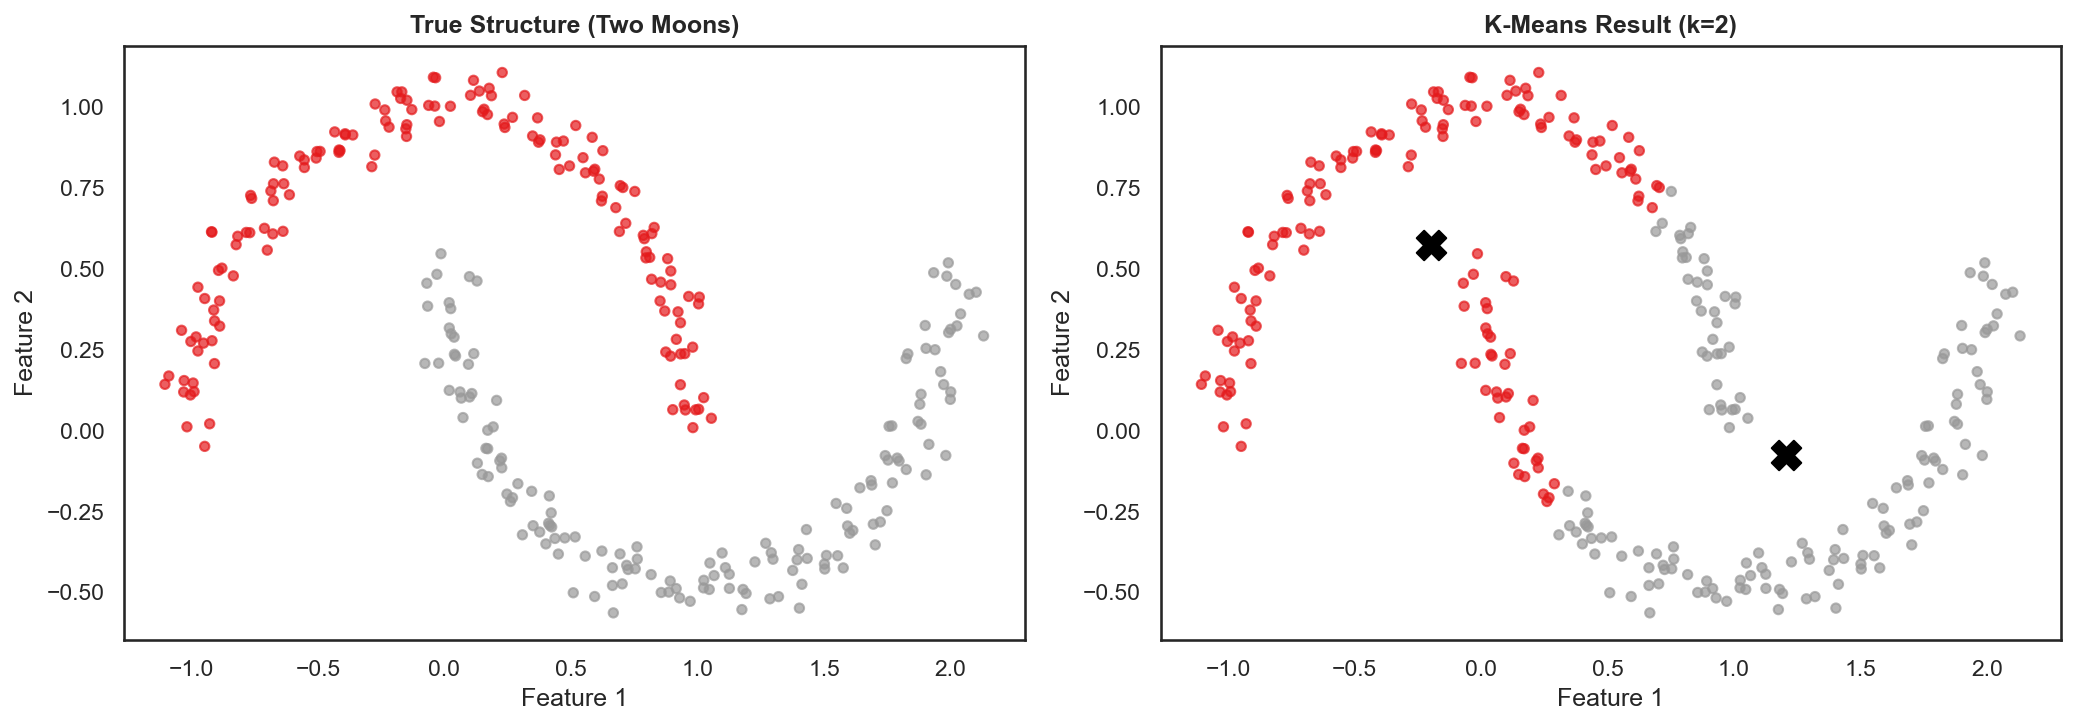

📌 K-Means CANNOT separate the two moons correctly!
   It splits them with a vertical line (nearest-centroid boundary).
   This is because K-Means can only make convex (blob-shaped) clusters.
   For non-convex shapes, you need density-based methods like DBSCAN,
   which we'll cover in the next lab.


In [17]:
# Generate two interleaving half-moons
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

# K-Means on moons
km_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
km_moons.fit(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True structure
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="Set1", s=20, alpha=0.7)
axes[0].set_title("True Structure (Two Moons)", fontweight="bold")

# K-Means result
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons.labels_, cmap="Set1", s=20, alpha=0.7)
axes[1].scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1],
               c="black", marker="X", s=200, zorder=5)
axes[1].set_title("K-Means Result (k=2)", fontweight="bold")

for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

print("📌 K-Means CANNOT separate the two moons correctly!")
print("   It splits them with a vertical line (nearest-centroid boundary).")
print("   This is because K-Means can only make convex (blob-shaped) clusters.")
print("   For non-convex shapes, you need density-based methods like DBSCAN,")
print("   which we'll cover in the next lab.")

---

## 12. Assigning New Data Points with `.predict()`

Once a K-Means model is fitted, you can assign **new customers** to the existing clusters using `.predict()`. This works by simply finding the nearest centroid.

In [18]:
# Imagine 3 new customers walk into the mall
new_customers = pd.DataFrame({
    "age": [25, 55, 35],
    "annual_income": [90, 30, 70],
    "spending_score": [80, 20, 50]
})

# Scale them the same way as the training data
new_scaled = scaler.transform(new_customers[feature_cols].values)

# Predict cluster assignments
new_labels = kmeans.predict(new_scaled)

print("New Customer Assignments:")
for i, (_, row) in enumerate(new_customers.iterrows()):
    print(f"  Customer {i+1}: Age={row['age']}, Income=${row['annual_income']}k, "
          f"Spending={row['spending_score']} → Cluster {new_labels[i]}")

print("\n📌 .predict() doesn't retrain the model — it just measures distance to each centroid")
print("   and assigns the new point to the nearest one.")
print("   IMPORTANT: You must scale new data with the SAME scaler used for training!")

New Customer Assignments:
  Customer 1: Age=25, Income=$90k, Spending=80 → Cluster 2
  Customer 2: Age=55, Income=$30k, Spending=20 → Cluster 0
  Customer 3: Age=35, Income=$70k, Spending=50 → Cluster 2

📌 .predict() doesn't retrain the model — it just measures distance to each centroid
   and assigns the new point to the nearest one.
   IMPORTANT: You must scale new data with the SAME scaler used for training!


---

## Summary

In this lab, we learned how to use scikit-learn's `KMeans` for clustering. Here's what we covered:

| Step | What We Did | Key API |
|------|-------------|--------|
| Load data | Mall Customers (200 samples, 3 features) | `pd.read_csv()` |
| Visual exploration | Spotted natural clusters in income-spending space | `plt.scatter()` |
| Scaling | StandardScaler to equalize feature ranges | `StandardScaler().fit_transform()` |
| Proved scaling matters | Compared clusters with/without scaling | Side-by-side plot |
| Fit K-Means | Trained the model with k=5 | `KMeans(n_clusters=5).fit()` |
| Inspected model | Labels, centroids (scaled + original), inertia | `.labels_`, `.cluster_centers_`, `.inertia_` |
| Chose k | Elbow Method — plotted inertia vs. k | Loop + `.inertia_` |
| Visualized clusters | 2D scatter + 3D scatter with centroids | `plt.scatter(c=labels)` |
| Profiled clusters | Computed mean features per cluster, named segments | `df.groupby('cluster').mean()` |
| Watched iteration | Froze K-Means mid-convergence to see centroids move | `max_iter` parameter |
| Initialization | Compared random vs. k-means++ | `init` parameter |
| Limitations | Showed K-Means fails on non-convex (moon) shapes | `make_moons()` |
| Prediction | Assigned new customers to existing clusters | `.predict()` |

The key takeaways are:

1. **K-Means requires scaling** — it uses Euclidean distance, so features with larger ranges dominate.
2. **Choosing k matters** — the Elbow Method plots inertia vs. k to find the sweet spot.
3. **Initialization matters** — `k-means++` is much more reliable than random initialization.
4. **Cluster profiling is the real value** — computing mean features per cluster tells you *what* each group is.
5. **K-Means assumes convex (blob-shaped) clusters** — it fails on complex shapes like moons or rings. For those, you need density-based methods.
6. **`.predict()`** assigns new data to the nearest centroid — but you must scale it with the same scaler.

---

**Next:** [DBSCAN and HDBSCAN Clustering Theory](./05_dbscan_and_hdbscan_clustering_theory.md)